In [19]:
import pandas as pd
import numpy as np
import random
import math
from numpy import pi
from numpy import sqrt
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

In [2]:
import sys
from pathlib import Path
import importlib

cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [3]:
from utils import init

dataset = init()


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2023728 entries, 0 to 2023727
Data columns (total 13 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CUA       str    
 1   City      str    
 2   GEOID     str    
 3   Grade     str    
 4   PHOLC     float64
 5   Asian     int64  
 6   Black     int64  
 7   Hispanic  int64  
 8   White     int64  
 9   Other     int64  
 10  Total     int64  
 11  NO2       float64
 12  PM25      float64
dtypes: float64(3), int64(6), str(4)
memory usage: 200.7 MB


USING APPROXIMATE AMPLITUDE AMPLIFICATION TO ENCODE DATA

In [29]:
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector

In [87]:
# Custom histogram plot to show difference between encoding and actual data

def bar_text( bars, ax, offset = 0.01, color = "black", set_height = False ):

    for bar in bars:
        height = bar.get_height()

        if set_height:
            ax.text(    bar.get_x() + bar.get_width() / 2,    offset,    f"{height:.2f}",    ha='center',    va='bottom',    fontsize=8 , color = color)
        else:
            ax.text(    bar.get_x() + bar.get_width() / 2,    height + offset,    f"{height:.2f}",    ha='center',    va='bottom',    fontsize=8 , color = color)

def custom_plot_dict_histogram( data_dict, bg_dict, label_ref, fig_size = (10,5), show_values = True, label_name_a =" AAE State", label_name_b =" Target State", label_string= True):

    fig, ax = plt.subplots( figsize= fig_size)

    all_labels = [ label for label in label_ref]
    
    if label_string is False:
        all_labels = [str(label) for label in label_ref]


    if bg_dict is not None:
        target_values = [ bg_dict.get( label, 0) for label in all_labels]

    data = data_dict
    dict_values = [ data.get(label, 0) for label in all_labels]

    #diff_values =
    if bg_dict is not None:
        max_v = max( max( dict_values), max( target_values ) ) + 0.05
    else:
        max_v = max( dict_values ) + 0.05

    if bg_dict is not None:    
        bars = ax.bar(all_labels, target_values, color = "red", alpha= 0.4, edgecolor='black', linewidth=1.2, label= label_name_b )
        if show_values:
            bar_text( bars, ax, max_v - 0.02, color= "red", set_height= True)

    
    barsb = ax.bar(all_labels, dict_values, color = "blue", alpha= 0.5, edgecolor='black', linewidth=1.2, label= label_name_a )
    if show_values:
        bar_text( barsb, ax, max_v - 0.03, color= "blue", set_height= True)


    # FIX: use correct scale
    ax.set_ylim(0, max_v)   # ← change from 100 to 1
    ax.set_xlabel("State")
    ax.set_ylabel("Probability")
    ax.legend(loc="best")#"upper right")
    plt.show()



Approximate Amplitude Encoding 

Ansatz: Hardware Efficient Ansatz (HEA)

In [185]:
#region: load conditions


bit_size = int( math.log2( data_size) )
layers = 4 

rotation_layers = 1
param_size = (bit_size *layers)*rotation_layers


#endregion


# region: Hilbert Space Mapping( Map to hilbert space )
def create_possibility_space( n=3):
    bit_space = 2**n
    all_states = [ format(i, f'0{n}b') for i in range( bit_space)]

    #print( "possibility space: ", all_states)
    return all_states

bn_size = int(bit_size)#int( math.log2(bit_size) )
bit_space = bit_size

all_states = create_possibility_space( bn_size)

#endregion

#region: Ansatz Configuration Functions

# AAE Prepare Search State
def gen_CNOT_list( size, type = 0):

    if (type == 0):
        cnot_list = [ [i, i+1] for i in range(size - 1) ]
    
        return cnot_list
    else:

        cnot_list = [ [ i, i+1] for i in range( 0, size - 1, 2) ]
        cnot_listb = [ [ i+1, i+2] for i in range( 0, size-2, 2) ]
        
        cnot_list.extend( cnot_listb)
        return cnot_list

#ansatz_format = "XZX" #xzx - (z_entaglement)
ansatz_format = "YYY"

def Apply_circuit_rotation(  pos, ansatz_format, circuit, parameter, circ_index):
    gate = ansatz_format[pos]

    rotations = {
        "X": circuit.rx,
        "Y": circuit.ry,
        "Z": circuit.rz
    }

    try:
        rotations[gate](parameter, circ_index)
    except KeyError:
        raise ValueError(f"Unknown rotation type '{gate}' at position {pos}")

# entangIement_format = 

def init_ansatz( inputs, layers, parameters):

    circ = QuantumCircuit( inputs , inputs)

    circ.barrier()

    #for inp in range( inputs):
        #circ.h(inp)

    circ.barrier()
    cnot_list = gen_CNOT_list( inputs, 1)
    #print( cnot_list)

    param_index = 0

    for n in range( layers):
        #circ.barrier()

        # group a (ry)
        for i in range( inputs):
            for rot in range( rotation_layers):
                Apply_circuit_rotation( 0, ansatz_format, circ, parameters[ param_index], i)
                param_index += 1
            


        #group b (cnot)
        for a,b in cnot_list:
            circ.cx( a,b)
        circ.barrier()
        
        #region: group c ( entangler)
        #for a,b in cnot_list:
        #    circ.cry( parameters[param_index], a, b)
        #    param_index += 1
        #circ.cry( parameters[param_index], inputs-1, 0)
        #endregion

    #print( circ)
    return circ

def append_ansatz( circ, inputs, offset, layers, parameters):


    circ.barrier()

    #for inp in range( inputs):
    #    circ.h(inp+offset)

    circ.barrier()
    cnot_list = gen_CNOT_list( inputs, 1)

    param_index = 0

    for n in range( layers):
        #circ.barrier()

        # group a (ry)
        for i in range( inputs):
            for rot in range( rotation_layers):
                Apply_circuit_rotation( 0, ansatz_format, circ, parameters[ param_index], i + offset)
                param_index += 1

        #group b (cnot)
        for a,b in cnot_list:
            circ.cx( offset + a, offset + b)
        circ.barrier()
        
        #region: group c ( entangler)
        #for a,b in cnot_list:
        #    circ.cry( parameters[param_index], a, b)
        #    param_index += 1
        #circ.cry( parameters[param_index], inputs-1, 0)
        #endregion

    #print( circ)
    return circ

def append_inverse_ansatz( circ, inputs, offset, layers, parameters, reverse_rotations= True, entangle_chain= True):

    parameters = parameters.reshape( layers,inputs)[::-1].flatten()

    circ.barrier()

    #for inp in range( inputs):
    #    circ.h(inp)

    circ.barrier()
    cnot_list = gen_CNOT_list( inputs, 1)

    param_index = 0

    for n in range( layers):
        #group b (cnot)
        circ.barrier()

        if entangle_chain: 
            for a,b in cnot_list[::-1]:
                circ.cx( offset + a, offset + b)

        circ.barrier()
        # group a (ry)
        for i in range( inputs):
            for rot in range( rotation_layers):

                sn = 1 if reverse_rotations else -1 #reverse rotation angle

                Apply_circuit_rotation( 0, ansatz_format, circ, sn*parameters[ param_index], i + offset)

                param_index += 1

        
        circ.barrier()
        
        #region: group c ( entangler)
        #for a,b in cnot_list:
        #    circ.cry( parameters[param_index], a, b)
        #    param_index += 1
        #circ.cry( parameters[param_index], inputs-1, 0)
        #endregion

        #for inp in range( inputs):
        #    circ.h(inp+offset)

    #print( circ)
    return circ

def extract_qc_output(qc):
    backend = Aer.get_backend("qasm_simulator")

    compiled_circuit = transpile(qc, backend)

    job = backend.run(compiled_circuit, shots=1024)
    result = job.result()

    counts = result.get_counts()

    # Convert to probabilities
    total_shots = sum(counts.values())
    probs = {key: value / total_shots for key, value in counts.items()}
    
    return probs

def extract_statevector_output(qc, reverse_bits=False):

    backend = Aer.get_backend("statevector_simulator")

    qc_sv = qc.remove_final_measurements(inplace=False)

    compiled_circuit = transpile(qc_sv, backend)
    result = backend.run(compiled_circuit).result()

    statevector = result.get_statevector()

    probs_dict = Statevector(statevector).probabilities_dict()

    if reverse_bits:
        probs_dict = {k[::-1]: v for k, v in probs_dict.items()}


    return probs_dict

def Measure_Probabilities( circ, method="qasm", reverse_bits=False ):

    if method=="qasm":
        # Choose backend
        backend = Aer.get_backend("qasm_simulator")

        compiled_circuit = transpile( circ, backend)


        job = backend.run(compiled_circuit, shots=1024)
        result = job.result()

        counts = result.get_counts()

        total_shots = sum(counts.values())
        prob_dict = { key: value/total_shots for key, value in counts.items() }

    else:
        backend = Aer.get_backend("statevector_simulator")

        qc_sv = circ.remove_final_measurements(inplace=False)

        compiled_circuit = transpile(qc_sv, backend)
        result = backend.run(compiled_circuit).result()

        statevector = result.get_statevector()

        prob_dict = Statevector(statevector).probabilities_dict()

    if reverse_bits:
        prob_dict = { k: v for k, v in prob_dict.items()}

    max_value_key = max( prob_dict, key= prob_dict.get)

    return max_value_key, prob_dict


#endregion

#region: AAE Training Optimizer Functions

def forward( parameters, _layers, input, base_circuit = None):
    # Bind parameters
    #bound_qc = circuit.bind_parameters({p: v for p, v in zip(circuit.parameters, weight_params)})
    
    if base_circuit is None:
        bound_qc = init_ansatz( input, _layers, parameters)
    else:
        bound_qc = append_ansatz( base_circuit, input, 0, _layers, parameters,reverse_rotations= False, entangle_chain= False )

    bound_qc.measure(range( input), range( input))
    #state_dict = extract_qc_output( bound_qc)
    state_dict = extract_statevector_output( bound_qc)
    return state_dict

# loss functions
def cross_entropy(prediction, target, possibility_space, eps=1e-12):
    return -sum(    target.get(s, 0) * math.log(prediction.get(s, eps) + eps)    for s in possibility_space )

def mse_loss( prediction, target, possibility_space):
    #mse = sum( ( prediction.get(s, 0) - target.get(s, 0))**2 for s in possibility_space) / len( possibility_space)
    mse = sum((prediction.get(s, 0) - target.get(s, 0))**2 for s in possibility_space)
    return mse

def AAE_Model(epoch=2, iterations=200, _method="COBYLA", input_size= 3, layers= 2, parameter_size = 4, encode_state= None, Hilbert_map= None, show_progress = True, _Base_circuit = None):


    epoch_records = []
    loss_records = []
    progress_records = []
    transform_records = []

    global_best_loss = float('inf')
    global_best_params = None
    patience = 50
    #no_improve_steps = 0
    #last_best = float('inf')

    params = np.random.uniform( -np.pi, np.pi, size=parameter_size)
    #params = np.array( [np.pi/2]*param_size)#np.random.uniform(-np.pi, np.pi, size=param_size)
    
    for i in range(epoch):

        if show_progress:
            print("epoch:", i)

        step = 0
        epoch_best_loss = float('inf')
        epoch_best_params = None

        last_best = float('inf')
        no_improve_steps = 0

        def loss_fn(p, repeats= 1):
            #return mse_loss( forward(p, input=input_size, base_circuit= _Base_circuit, _layers= layers), encode_state, Hilbert_map)
            return 1000*sum( mse_loss( forward(p, input=input_size, _layers= layers), encode_state, Hilbert_map ) for _ in range(repeats) ) / repeats
            #return sum( cross_entropy( forward(p, input=input_size, _layers= layers), encode_state, Hilbert_map ) for _ in range(repeats) ) / repeats
        
        def callback(xk):
            nonlocal no_improve_steps, last_best
            nonlocal step, epoch_best_loss, epoch_best_params
            nonlocal global_best_loss, global_best_params
            best_check = ""

            step += 1

            loss = loss_fn(xk)
            
            # early stopping patience tracking
            if loss < last_best - 1e-6:
                last_best = loss
                no_improve_steps = 0
            else:
                no_improve_steps += 1

            # epoch best
            if loss < epoch_best_loss:
                epoch_best_loss = loss
                epoch_best_params = xk.copy()

            # global best + RECORD
            if loss < global_best_loss:
                global_best_loss = loss
                global_best_params = xk.copy()
                
                progress_records.append( [ i, loss])

                if show_progress:
                    #print("New Global Best:", global_best_loss)
                    best_check = ": New Global Best."

            loss_records.append(loss)
            transform_records.append(xk.copy())
            epoch_records.append( i)

            if show_progress:
                print("step:", step, "loss:", loss, best_check)


            if ( show_progress and step % 50 == 0):
                print("step:", step, "loss:", loss, "epoch best:", epoch_best_loss)
        
        
        res = minimize( loss_fn, params, method=_method, callback=callback, options={"maxiter": iterations} )
        
        # choose next starting point
        if epoch_best_params is not None:
            params = epoch_best_params
        else:
            params = res.x


        if show_progress:
            print("done: Best loss:", global_best_loss)
            

        # early stopping if perfect encoding
        if global_best_loss <= 0.0:  
            break
        
        if no_improve_steps >= patience:
            break
    return transform_records, loss_records, epoch_records, progress_records

#endregion



In [213]:
# prepare data for quantum circuit
def data_to_quantum_state( data, hilbert_map):

    normalized_data = np.array( data.copy(), dtype=np.float64)

    norm_sum = np.sum( normalized_data) #np.sum( normalized_data**2 )
    if norm_sum == 0:
        return None, 0
    else:
        normalized_data /= norm_sum#sqrt( norm_sum )


    
    hb_size = len( hilbert_map)
    quantum_state = { hilbert_map[i]: 0.0 for i in range( hb_size) } # map the full hilbert space
    
    data_size = len( data)
    qs_keys = hilbert_map[:data_size]

    for i in range( data_size):
        if qs_keys[i] in quantum_state:
            quantum_state[ qs_keys[i] ] = normalized_data[i]

    return quantum_state, norm_sum


def quantum_state_to_data( state, normalize_factor,  size_xy):
    res_grid = [0]*( size_xy)

    dl_frac, init_qubit_size = math.modf( math.log2( size_xy) )

    # simple padding ( if qubit size is not enough )
    if dl_frac > 0:
        init_qubit_size += 1


    init_qubit_size = int( init_qubit_size)

    label_ref = create_possibility_space( init_qubit_size)

    st_count = size_xy #use actual size not hilbert space size ( to account for padding)

    for i in range( st_count):
        if label_ref[i] in state:
            res_grid[i] =  state[ label_ref[i] ]


    #res_grid = [ (i* normalize_factor)**0.5 for i in res_grid ]
    res_grid = [ (i* normalize_factor) for i in res_grid ]
    res_grid = np.array( res_grid)

    return res_grid


def AAE_prepare_target_State(  data):
    #Note: use 1d arrays 
    data_len = len( data)
    dl_frac, qubit_size = math.modf( math.log2( data_len) )


    # simple padding ( if qubit size is not enough )
    if dl_frac > 0:
        qubit_size += 1


    qubit_size = int( qubit_size)
    

    hilbert_space_size = 2**qubit_size

    hilbert_space = create_possibility_space( qubit_size)

    quantum_state, normalize_factor  = data_to_quantum_state( data , hilbert_space)
    
    return quantum_state, normalize_factor, qubit_size, hilbert_space

def AAE_Reconstruct_Data( state_dict, normalize_factor, data_set_offset, original_data_size, original_data_shape):
    _data = quantum_state_to_data( state_dict, normalize_factor, original_data_size)

    data_recon = _data + data_set_offset

    AAE_recon_data = np.reshape( data_recon, original_data_shape )
    
    return AAE_recon_data


Data Encoding: Intra Urban

In [5]:
from utils import collect_data_intraurban_diff

no2_intraurban_diff  = collect_data_intraurban_diff(dataset, 'PHOLC', 'NO2')

In [27]:
print( len(no2_intraurban_diff ) )

5


In [ ]:
def generate_plot(data, axes, x_label, y_label, y_min, y_max, y_ticks, plot_name):
   fig, ax = plt.subplots()
   ax.plot(axes, data[0], 'g--', label = 'Hispanic')
   ax.plot(axes, data[1], 'b:', label = 'Asian')
   ax.plot(axes, data[2], 'm-', label = 'Black')
   ax.plot(axes, data[3], 'k-', label = 'Total')
   ax.plot(axes, data[4], 'm--', label = 'White')
   ax.axhline(y = 0, color = 'grey', linestyle = '-', linewidth = 1)
   ax.set_xlabel(x_label)
   ax.set_ylabel(y_label)
   ax.set_ylim(y_min, y_max)
   ax.set_yticks(y_ticks)
   ax.legend()
   plt.title( plot_name)
   plt.show()




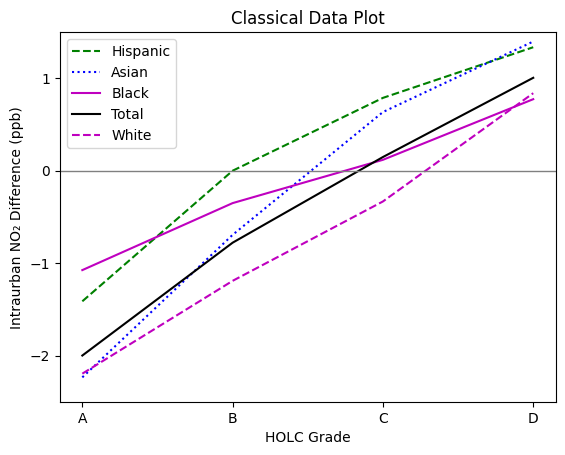

In [21]:
axes = ['A', 'B', 'C', 'D']

generate_plot(no2_intraurban_diff, axes, 'HOLC Grade', 'Intraurban NO₂ Difference (ppb)', -2.5, 1.5, (-2, -1, 0, 1), 'Classical Data Plot')

In [217]:
# Prepare target state

no2_intraurban_diff_np = np.array( no2_intraurban_diff )

# get shape for recon
intd_data_shape = no2_intraurban_diff_np.shape

# flatten   
no2_intraurban_diff_flat = no2_intraurban_diff_np.flatten() 

# get size
intd_data_size = len( no2_intraurban_diff_flat)

# Note all data inputs must be positive
intd_negative_offset = abs( np.min( no2_intraurban_diff_flat) )

no2_intraurban_diff_offset = no2_intraurban_diff_flat + intd_negative_offset



intd_target_state, intd_normalize_factor, intd_qubit_size, intd_hilbert_space= AAE_prepare_target_State(  no2_intraurban_diff_offset)

print( intd_target_state)
print( intd_normalize_factor, intd_negative_offset)
print( intd_qubit_size, len(intd_hilbert_space) )


{'00000': 0.020840262265019956, '00001': 0.056613684438503585, '00010': 0.07657336291207321, '00011': 0.09044964065511993, '00100': 0.0, '00101': 0.03904754830907901, '00110': 0.0726903143647913, '00111': 0.09201234877412869, '01000': 0.029386186485182347, '01001': 0.04774153772613933, '01010': 0.05960331682905719, '01011': 0.07621383162826835, '01100': 0.005980226937725636, '01101': 0.036895954031315605, '01110': 0.06036709036193625, '01111': 0.08207218905331355, '10000': 0.001014732447661932, '10001': 0.026444525564760322, '10010': 0.048193548105376974, '10011': 0.07785969911054695, '10100': 0.0, '10101': 0.0, '10110': 0.0, '10111': 0.0, '11000': 0.0, '11001': 0.0, '11010': 0.0, '11011': 0.0, '11100': 0.0, '11101': 0.0, '11110': 0.0, '11111': 0.0}
39.500867077786594 2.2363256300970993
5 32


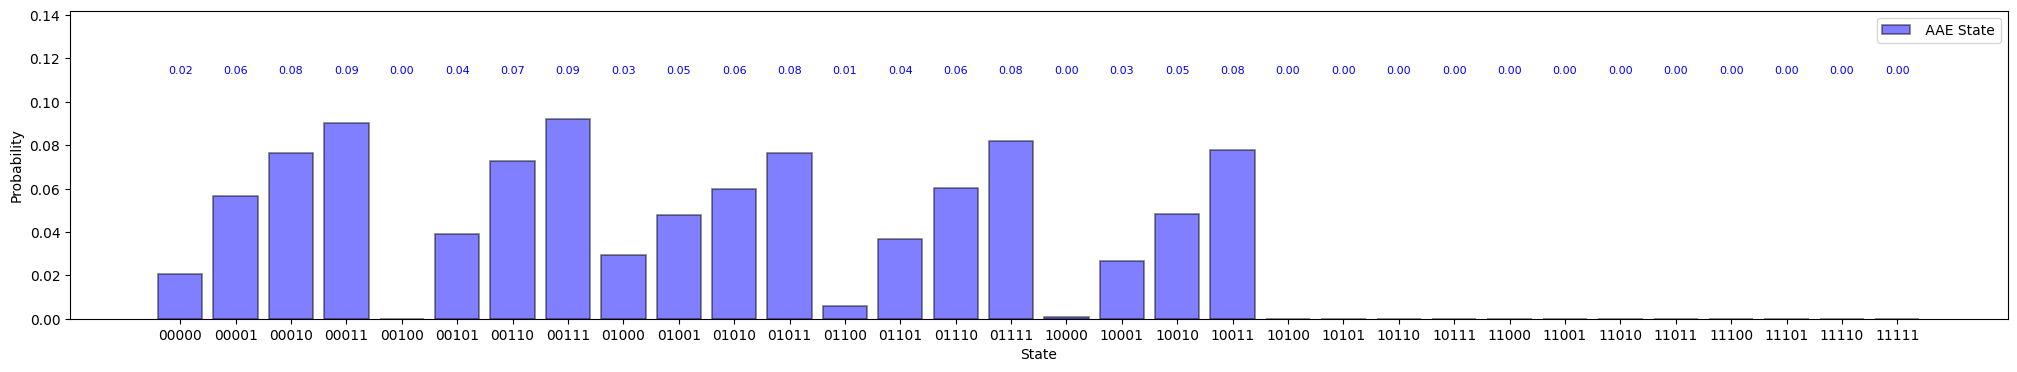

In [166]:
custom_plot_dict_histogram( intd_target_state, None, intd_hilbert_space, fig_size=( 25,4))

In [210]:
layers = 8

rotation_layers = 1
param_size = (intd_qubit_size *layers)*rotation_layers

epoch_set = 20

intd_transform_records, intd_loss_records, intd_epoch_records, intd_progress_records = AAE_Model( epoch= epoch_set, input_size= intd_qubit_size, layers= layers, parameter_size= param_size, encode_state= intd_target_state, Hilbert_map= intd_hilbert_space, show_progress= True)


epoch: 0
step: 1 loss: 38.71188218909042 : New Global Best.
step: 2 loss: 38.71188218909042 
step: 3 loss: 38.50764479108084 : New Global Best.
step: 4 loss: 38.50764479108084 
step: 5 loss: 33.678893753434764 : New Global Best.
step: 6 loss: 33.678893753434764 
step: 7 loss: 33.678893753434764 
step: 8 loss: 32.31119544321267 : New Global Best.
step: 9 loss: 24.20638329797426 : New Global Best.
step: 10 loss: 24.20638329797426 
step: 11 loss: 24.20638329797426 
step: 12 loss: 24.20638329797426 
step: 13 loss: 24.20638329797426 
step: 14 loss: 24.20638329797426 
step: 15 loss: 24.20638329797426 
step: 16 loss: 24.20638329797426 
step: 17 loss: 24.20638329797426 
step: 18 loss: 24.20638329797426 
step: 19 loss: 24.20638329797426 
step: 20 loss: 24.20638329797426 
step: 21 loss: 24.20638329797426 
step: 22 loss: 23.903985677030377 : New Global Best.
step: 23 loss: 23.903985677030377 
step: 24 loss: 23.903985677030377 
step: 25 loss: 23.903985677030377 
step: 26 loss: 23.903985677030377 


AAE Circuit and Encoded Data Extraction

In [211]:

intd_state = init_ansatz( intd_qubit_size, layers, intd_transform_records[-1] )
intd_state.measure( range( intd_qubit_size), range( intd_qubit_size) )
intd_state.draw()


░  ░  ┌────────────┐           ░ ┌──────────────┐           ░ »
q_0: ─░──░──┤ Ry(2.3324) ├──■────────░─┤ Ry(-0.57593) ├──■────────░─»
      ░  ░  ├────────────┤┌─┴─┐      ░ └┬────────────┬┘┌─┴─┐      ░ »
q_1: ─░──░──┤ Ry(1.4462) ├┤ X ├──■───░──┤ Ry(3.2156) ├─┤ X ├──■───░─»
      ░  ░ ┌┴────────────┤└───┘┌─┴─┐ ░  ├────────────┤ └───┘┌─┴─┐ ░ »
q_2: ─░──░─┤ Ry(-2.9367) ├──■──┤ X ├─░──┤ Ry(1.0524) ├───■──┤ X ├─░─»
      ░  ░ └┬────────────┤┌─┴─┐└───┘ ░  ├────────────┤ ┌─┴─┐└───┘ ░ »
q_3: ─░──░──┤ Ry(2.5725) ├┤ X ├──■───░──┤ Ry(2.7168) ├─┤ X ├──■───░─»
      ░  ░ ┌┴────────────┤└───┘┌─┴─┐ ░ ┌┴────────────┴┐└───┘┌─┴─┐ ░ »
q_4: ─░──░─┤ Ry(0.65963) ├─────┤ X ├─░─┤ Ry(0.022736) ├─────┤ X ├─░─»
      ░  ░ └─────────────┘     └───┘ ░ └──────────────┘     └───┘ ░ »
c: 5/═══════════════════════════════════════════════════════════════»
                                                                    »
«     ┌──────────────┐           ░  ┌─────────────┐            ░ »
«q_0: ┤ Ry(-0.64774) ├──■────────░──┤ Ry(-2.1676) ├───■────────░─»
«     ├─────────────┬┘┌─┴─┐      ░  ├─────────────┴┐┌─┴─┐      ░ »
«q_1: ┤ Ry(-1.8696) ├─┤ X ├──■───░──┤ Ry(-0.45622) ├┤ X ├──■───░─»
«     └┬───────────┬┘ └───┘┌─┴─┐ ░ ┌┴──────────────┤└───┘┌─┴─┐ ░ »
«q_2: ─┤ Ry(4.292) ├────■──┤ X ├─░─┤ Ry(-0.056197) ├──■──┤ X ├─░─»
«      ├───────────┴┐ ┌─┴─┐└───┘ ░ └─┬────────────┬┘┌─┴─┐└───┘ ░ »
«q_3: ─┤ Ry(3.2818) ├─┤ X ├──■───░───┤ Ry(1.2012) ├─┤ X ├──■───░─»
«     ┌┴────────────┤ └───┘┌─┴─┐ ░  ┌┴────────────┤ └───┘┌─┴─┐ ░ »
«q_4: ┤ Ry(-2.7135) ├──────┤ X ├─░──┤ Ry(-1.3076) ├──────┤ X ├─░─»
«     └─────────────┘      └───┘ ░  └─────────────┘      └───┘ ░ »
«c: 5/═══════════════════════════════════════════════════════════»
«                                                                »
«     ┌──────────────┐           ░  ┌────────────┐           ░ ┌─────────────┐»
«q_0: ┤ Ry(-0.75157) ├──■────────░──┤ Ry(1.0828) ├──■────────░─┤ Ry(-3.8629) ├»
«     ├─────────────┬┘┌─┴─┐      ░  ├────────────┤┌─┴─┐      ░ └┬────────────┤»
«q_1: ┤ Ry(0.41171) ├─┤ X ├──■───░──┤ Ry(1.7217) ├┤ X ├──■───░──┤ Ry(1.5388) ├»
«     ├─────────────┤ └───┘┌─┴─┐ ░ ┌┴────────────┤└───┘┌─┴─┐ ░  ├────────────┤»
«q_2: ┤ Ry(-3.3077) ├───■──┤ X ├─░─┤ Ry(-1.8332) ├──■──┤ X ├─░──┤ Ry(1.3318) ├»
«     └┬────────────┤ ┌─┴─┐└───┘ ░ └┬────────────┤┌─┴─┐└───┘ ░  ├────────────┤»
«q_3: ─┤ Ry(1.5437) ├─┤ X ├──■───░──┤ Ry(2.1151) ├┤ X ├──■───░──┤ Ry(1.4437) ├»
«     ┌┴────────────┴┐└───┘┌─┴─┐ ░  ├────────────┤└───┘┌─┴─┐ ░  ├────────────┤»
«q_4: ┤ Ry(-0.06542) ├─────┤ X ├─░──┤ Ry(2.3437) ├─────┤ X ├─░──┤ Ry(-2.843) ├»
«     └──────────────┘     └───┘ ░  └────────────┘     └───┘ ░  └────────────┘»
«c: 5/════════════════════════════════════════════════════════════════════════»
«                                                                             »
«                ░ ┌─────────────┐           ░ ┌─┐            
«q_0: ──■────────░─┤ Ry(-3.4721) ├──■────────░─┤M├────────────
«     ┌─┴─┐      ░ ├─────────────┤┌─┴─┐      ░ └╥┘┌─┐         
«q_1: ┤ X ├──■───░─┤ Ry(-0.8211) ├┤ X ├──■───░──╫─┤M├─────────
«     └───┘┌─┴─┐ ░ ├─────────────┤└───┘┌─┴─┐ ░  ║ └╥┘┌─┐      
«q_2: ──■──┤ X ├─░─┤ Ry(0.24013) ├──■──┤ X ├─░──╫──╫─┤M├──────
«     ┌─┴─┐└───┘ ░ ├─────────────┤┌─┴─┐└───┘ ░  ║  ║ └╥┘┌─┐   
«q_3: ┤ X ├──■───░─┤ Ry(-3.2308) ├┤ X ├──■───░──╫──╫──╫─┤M├───
«     └───┘┌─┴─┐ ░ ├─────────────┤└───┘┌─┴─┐ ░  ║  ║  ║ └╥┘┌─┐
«q_4: ─────┤ X ├─░─┤ Ry(0.53575) ├─────┤ X ├─░──╫──╫──╫──╫─┤M├
«          └───┘ ░ └─────────────┘     └───┘ ░  ║  ║  ║  ║ └╥┘
«c: 5/══════════════════════════════════════════╩══╩══╩══╩══╩═
«                                               0  1  2  3  4

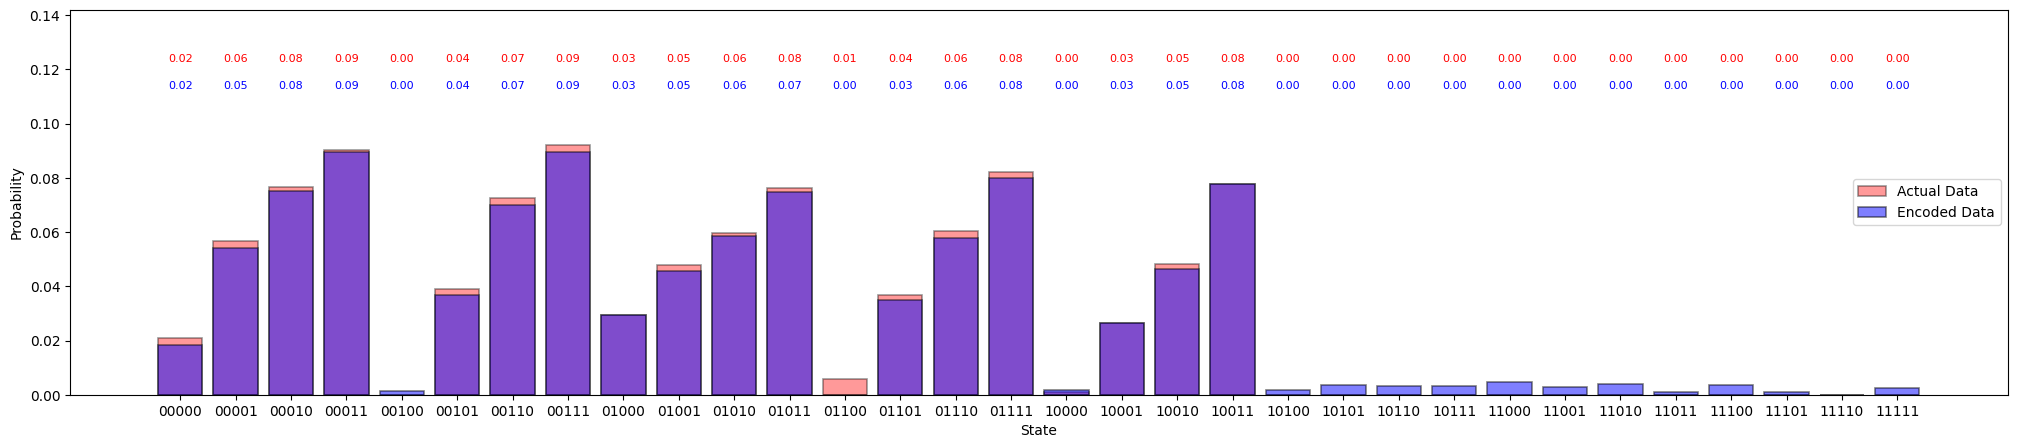

In [212]:
# Show Encoding Accuracy
res_b, res_prob = Measure_Probabilities(  intd_state, method="statevector", reverse_bits=True )
custom_plot_dict_histogram( res_prob, intd_target_state, intd_hilbert_space, fig_size=(25,5), label_name_a="Encoded Data", label_name_b="Actual Data")
id_ref = list( range( intd_qubit_size) )

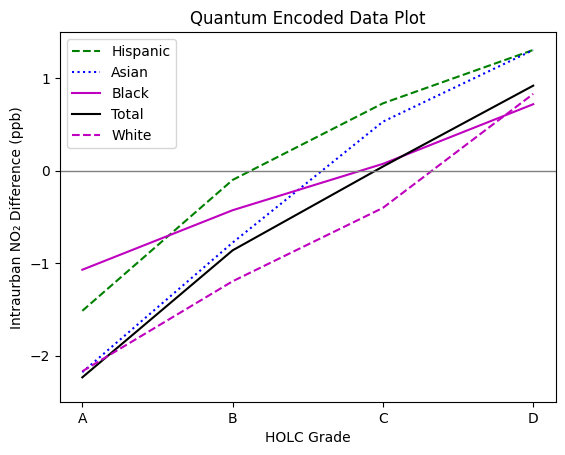

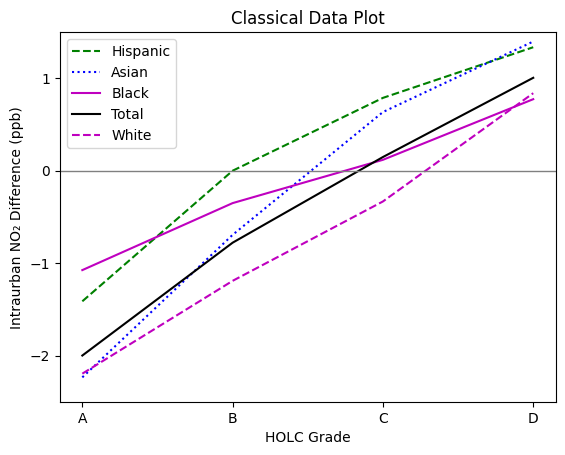

In [219]:
# Reconstruct Encoded Data

quantum_encoded_no2_intraurban_diff_data = AAE_Reconstruct_Data( res_prob, intd_normalize_factor, -intd_negative_offset, intd_data_size, intd_data_shape )#np.reshape( intd_data_recon, (5,4) )

axes = ['A', 'B', 'C', 'D']

generate_plot( quantum_encoded_no2_intraurban_diff_data, axes, 'HOLC Grade', 'Intraurban NO₂ Difference (ppb)', -2.5, 1.5, (-2, -1, 0, 1), 'Quantum Encoded Data Plot')

generate_plot( no2_intraurban_diff, axes, 'HOLC Grade', 'Intraurban NO₂ Difference (ppb)', -2.5, 1.5, (-2, -1, 0, 1), 'Classical Data Plot')

AAE Encoding 2: large data encoding ( 64 values test)

In [220]:
#Grab Baltimore Total Data

store_kys = []
store_dts = []

for i in range( 7882, 10000):
    if "Baltimore" in dataset["CUA"].iloc[i]:
        store_kys.append(dataset["CUA"].iloc[i])
        store_dts.append(dataset["Total"].iloc[i])


In [221]:
data_size = 64

trend_dict = { i:store_dts[i] for i in range(data_size)} 

{0: 13, 1: 267, 2: 39, 3: 99, 4: 39, 5: 89, 6: 49, 7: 87, 8: 73, 9: 44, 10: 41, 11: 63, 12: 45, 13: 47, 14: 136, 15: 164, 16: 23, 17: 32, 18: 88, 19: 105, 20: 165, 21: 124, 22: 59, 23: 95, 24: 41, 25: 135, 26: 343, 27: 85, 28: 63, 29: 284, 30: 78, 31: 136, 32: 78, 33: 55, 34: 64, 35: 76, 36: 46, 37: 60, 38: 44, 39: 33, 40: 96, 41: 101, 42: 36, 43: 92, 44: 53, 45: 18, 46: 351, 47: 15, 48: 108, 49: 109, 50: 114, 51: 63, 52: 164, 53: 92, 54: 88, 55: 59, 56: 45, 57: 36, 58: 31, 59: 37, 60: 363, 61: 69, 62: 99, 63: 71}


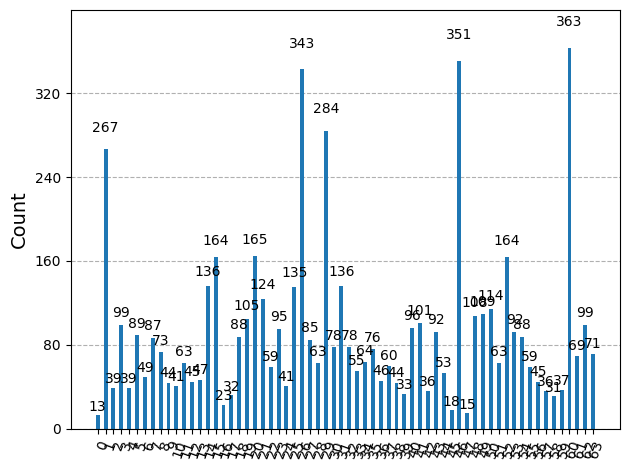

In [222]:
print( trend_dict)


plot_histogram( trend_dict)

In [16]:
target_state, nsum = data_to_quantum_state( list( trend_dict.values() ), all_states )
print( target_state, nsum)

{'0000': 0.010038610038610039, '0001': 0.20617760617760617, '0010': 0.030115830115830116, '0011': 0.07644787644787644, '0100': 0.030115830115830116, '0101': 0.06872586872586872, '0110': 0.03783783783783784, '0111': 0.06718146718146718, '1000': 0.05637065637065637, '1001': 0.03397683397683398, '1010': 0.03166023166023166, '1011': 0.04864864864864865, '1100': 0.03474903474903475, '1101': 0.036293436293436294, '1110': 0.10501930501930502, '1111': 0.12664092664092663} 1295.0


In [ ]:
epoch_set = 2

transform_records, loss_records, epoch_records, progress_records = AAE_Model( epoch= epoch_set, input_size= bit_size, layers= layers, parameter_size= param_size, encode_state= target_state, Hilbert_map=all_states, show_progress= True)


epoch: 0
step: 1 loss: 35.11409030408745 : New Global Best.
step: 2 loss: 33.092953751737376 : New Global Best.
step: 3 loss: 33.092953751737376 
step: 4 loss: 31.508997359955057 : New Global Best.
step: 5 loss: 31.508997359955057 
step: 6 loss: 31.508997359955057 
step: 7 loss: 31.412766076142738 : New Global Best.
step: 8 loss: 28.24034077142813 : New Global Best.
step: 9 loss: 20.341536674877595 : New Global Best.
step: 10 loss: 16.419004874496547 : New Global Best.
step: 11 loss: 12.38020737882086 : New Global Best.
step: 12 loss: 11.46421932042622 : New Global Best.
step: 13 loss: 11.20931635139385 : New Global Best.
step: 14 loss: 11.20931635139385 
step: 15 loss: 11.20931635139385 
step: 16 loss: 11.20931635139385 
step: 17 loss: 11.20931635139385 
step: 18 loss: 11.049797599288368 : New Global Best.
step: 19 loss: 10.713092125058655 : New Global Best.
step: 20 loss: 10.20103557555332 : New Global Best.
step: 21 loss: 10.08328151840796 : New Global Best.
step: 22 loss: 10.048031

In [18]:

state = init_ansatz( bit_size, layers, transform_records[-1] )
state.measure( range( bit_size), range( bit_size) )
state.draw()


░  ░ ┌──────────────┐           ░ ┌─────────────┐            ░ »
q_0: ─░──░─┤ Ry(0.034911) ├──■────────░─┤ Ry(-1.0288) ├───■────────░─»
      ░  ░ └┬────────────┬┘┌─┴─┐      ░ ├─────────────┤ ┌─┴─┐      ░ »
q_1: ─░──░──┤ Ry(3.9657) ├─┤ X ├──■───░─┤ Ry(-1.3852) ├─┤ X ├──■───░─»
      ░  ░ ┌┴────────────┤ └───┘┌─┴─┐ ░ └┬────────────┤ └───┘┌─┴─┐ ░ »
q_2: ─░──░─┤ Ry(-1.1454) ├───■──┤ X ├─░──┤ Ry(4.5028) ├───■──┤ X ├─░─»
      ░  ░ ├─────────────┤ ┌─┴─┐└───┘ ░ ┌┴────────────┴┐┌─┴─┐└───┘ ░ »
q_3: ─░──░─┤ Ry(0.19286) ├─┤ X ├──────░─┤ Ry(-0.56527) ├┤ X ├──────░─»
      ░  ░ └─────────────┘ └───┘      ░ └──────────────┘└───┘      ░ »
c: 4/════════════════════════════════════════════════════════════════»
                                                                     »
«      ┌────────────┐           ░ ┌─────────────┐           ░ ┌─┐         
«q_0: ─┤ Ry(2.9895) ├──■────────░─┤ Ry(0.27394) ├──■────────░─┤M├─────────
«     ┌┴────────────┤┌─┴─┐      ░ └┬────────────┤┌─┴─┐      ░ └╥┘┌─┐      
«q_1: ┤ Ry(0.45059) ├┤ X ├──■───░──┤ Ry(2.1621) ├┤ X ├──■───░──╫─┤M├──────
«     ├─────────────┤└───┘┌─┴─┐ ░  ├────────────┤└───┘┌─┴─┐ ░  ║ └╥┘┌─┐   
«q_2: ┤ Ry(-2.7187) ├──■──┤ X ├─░──┤ Ry(2.5666) ├──■──┤ X ├─░──╫──╫─┤M├───
«     └┬────────────┤┌─┴─┐└───┘ ░ ┌┴────────────┤┌─┴─┐└───┘ ░  ║  ║ └╥┘┌─┐
«q_3: ─┤ Ry(2.0848) ├┤ X ├──────░─┤ Ry(0.23568) ├┤ X ├──────░──╫──╫──╫─┤M├
«      └────────────┘└───┘      ░ └─────────────┘└───┘      ░  ║  ║  ║ └╥┘
«c: 4/═════════════════════════════════════════════════════════╩══╩══╩══╩═
«                                                              0  1  2  3

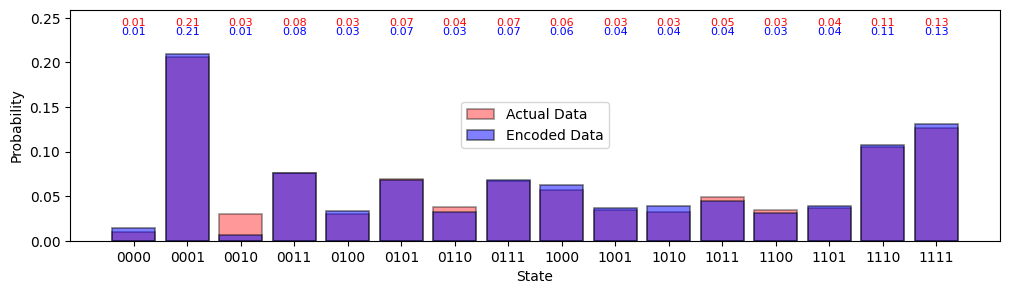

In [25]:
#res_b, res_prob = Measure_Probabilities(  state, method="statevector", reverse_bits=True )
res_prob = extract_statevector_output( state)#forward( transform_records[-1], 4, bit_size, None)
recon_data = quantum_state_to_data( res_prob, nsum, data_size)
recon_dict = {i:recon_data[i] for i in range(len(recon_data) ) }
custom_plot_dict_histogram( res_prob, target_state, all_states, fig_size=(12,3), label_name_a="Encoded Data", label_name_b="Actual Data")
id_ref = list( range( data_size) )

#custom_plot_dict_histogram( recon_dict, trend_dict, id_ref)

In [23]:
print( trend_dict)
print( recon_dict)

{0: 13, 1: 267, 2: 39, 3: 99, 4: 39, 5: 89, 6: 49, 7: 87, 8: 73, 9: 44, 10: 41, 11: 63, 12: 45, 13: 47, 14: 136, 15: 164}
{0: 17.947056028715547, 1: 270.7555436265443, 2: 7.70209234363849, 3: 98.70988346829182, 4: 43.32060216522341, 5: 88.50079861911614, 6: 42.02863667599541, 7: 88.84865185973663, 8: 81.15439291773619, 9: 48.051899415640044, 10: 51.037699296228034, 11: 58.269622937268714, 12: 40.795445877622996, 13: 50.41237982472256, 14: 138.6123146587443, 15: 168.8529802847755}
